# **Laboratorio N°3: Intuicion estadistica**

**Curso:** Aprendizaje Estadistico 2026-2  
**Estudiante:** Jeronimo Lopez Gomez


## Model Selection and Train/Validation/Test Sets
[1] Reference http://cs229.stanford.edu/syllabus.html

Just because a learning algorithm fits a training set well, that does not mean it is a good hypothesis. It could over fit and as a result your predictions on the test set would be poor. The error of your hypothesis as measured on the data set with which you trained the parameters will be lower than the error on any other data set.
Given many models with different complexities (for example polynomial degree), we can use a systematic approach to identify the 'best' function. In order to choose the model of your hypothesis, you can test each degree of polynomial and look at the error result.

One way to break down our dataset into the three sets is:
Training set: 60%
Cross validation set: 20%
Test set: 20%

We can now calculate three separate error values for the three different sets using the following method:
1. Optimize the parameters in Θ using the training set for each polynomial degree.
2. Find the polynomial degree d with the least error using the cross validation set.
3. Estimate the generalization error using the test set with J_{test}

This way, the degree of the polynomial d has not been trained using the test set.

------

## **Desarrollo**


**1.** Para los modelos generados en la sesión 3 tomar el 20% como datos para realizar el test y el 80% para realizar el entrenamiento y la validacion cruzada (por ejemplo 70% entrenamiento y 10% validacion cruzada). Construir una curva del score en función del parámetro gamma del clasificador que se esta empleando. ¿Cual presenta una mejor solución al problema?.



In [77]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import learning_curve
from sklearn.datasets import load_digits
from sklearn.model_selection import ShuffleSplit, GridSearchCV
from sklearn.naive_bayes import GaussianNB

In [68]:
# Datos bivariantes usados en la sesion 3.

def data( mu=[-1.2, 0.2], mu1=[-1.5, 1.5], cov=[[1.0, 0.0], [0.0, 1.0]] , cov1= [[1.0, -0.5], [-0.5, 1.0]]):
  rv = multivariate_normal(mu, cov)
  rv1 = multivariate_normal(mu1, cov1)
  return rv, rv1

rng = np.random.RandomState(42) #para reproducibilidad de los resultados
rv_0 = data()[0]
rv_1 = data()[1]


def sample(rv_0, rv_1, N1= 1000, N2 = 100,  r = 0.2):
  """
  Genera una muestra de datos de dos distribuciones multivariantes.
  N1: Número de muestras de la primera distribución (rv_0).
  N2: Número de muestras de la segunda distribución (rv_1).
  r: Semilla para la generación de números aleatorios para la mezcla de las muestras.
  """
  X_t = np.concatenate([rv_0.rvs(N1, random_state = r  ), rv_1.rvs(N2,random_state = r)])
  y   = np.concatenate([np.zeros(N1), np.ones(N2) ]  )
  return X_t, y

X, y = sample(rv_0, rv_1, N1=500, N2=500, r=10)

# Separacion de los datos en 80% para train / cross-validation y 20% para test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=1, stratify=y
)
# Del 80%, 70% para entrenamiento y 10% para validacion o sea 10/80 = 0.125
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.125, random_state=1, stratify=y_train
)
print(f'Tamanos:\nDataset Entrenamiento={len(y_train)},\nDataset de validacion={len(y_val)},\nDataset de test={len(y_test)}')

Tamanos:
Dataset Entrenamiento=700,
Dataset de validacion=100,
Dataset de test=200


In [69]:
# Curva del score en funcion de gamma para un SVC (Support Vector Classifier).
#Queremos explorar entre valores de gamma de diferente orden de magnitud, por eso usamos logspace
gammas = np.logspace(-3, 2, 25)

train_scores, val_scores = [], []

# Entrenamiento de un SVC para cada valor de gamma y calculo del score en train y validacion.
for gamma in gammas:
    # Se usa exactamente el clasificador de la sesion 3.
    clf = SVC(gamma=gamma)
    clf.fit(X_train, y_train)

    train_scores.append(clf.score(X_train, y_train))
    val_scores.append(clf.score(X_val, y_val))

best_index = np.argmax(val_scores)
best_gamma = gammas[best_index]

print("Mejor gamma:", best_gamma.round(3))
print(f'Score de validacion: {val_scores[best_index]:.3f}')

# Se reentrena con todo el 80% de desarrollo y se evalua en el 20% de test.
clf_final = SVC(gamma=best_gamma)
clf_final.fit(X_train, y_train)
score_test = clf_final.score(X_test, y_test)
print(f'Score de test: {score_test:.3f}')

Mejor gamma: 0.316
Score de validacion: 0.800
Score de test: 0.805


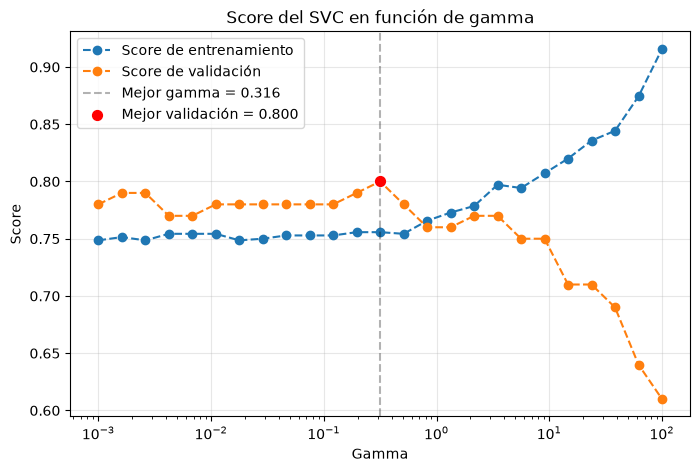

In [70]:
#Grafica de los scores de entrenamiento y validacion en funcion de gamma.

fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogx(gammas, train_scores,"o--", color="tab:blue", label="Score de entrenamiento")
ax.semilogx(gammas, val_scores,"o--", color="tab:orange", label="Score de validación")
ax.axvline(best_gamma, color="black", linestyle="--", label=f"Mejor gamma = {best_gamma:.3f}", alpha = 0.3)
ax.scatter(best_gamma, val_scores[best_index], color="red", s=50, zorder=5,
           label=f"Mejor validación = {val_scores[best_index]:.3f}")

ax.set_title("Score del SVC en función de gamma")
ax.set_xlabel("Gamma")
ax.set_ylabel("Score")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

De acuerdo con la curva del score en función del parámetro gamma, el mejor valor encontrado es gamma = 0.316. Este valor presenta el mayor score sobre el conjunto de validación, con un desempeño de aproximadamente 0.80. Al evaluar el modelo final sobre el conjunto de test, se obtiene un score de 0.805, lo que indica que el modelo generaliza de manera similar a su desempeño durante la validación.

-----


*Funciones de Graficacion Auxiliares (Desde el notebook Sesion 03 Intuicion Estadistica)*

`plot_learning_curve()`

`make_meshgrid()`

`plot_Contours()`

`plot_ContoursExact()`

In [71]:
#En esta celda importamos las librerias necesarias para graficar la curva de aprendizaje y la frontera de decision del SVC.
#Obtenidas del notebook de la sesion 3 del curso de Aprendizaje Estadistico
def plot_learning_curve(
    estimator,
    title,
    X,
    y,
    axes=None,
    ylim=None,
    cv=None,
    n_jobs=None,
    train_sizes=np.linspace(0.1, 1.0, 5),
):
    """
    Generate 3 plots: the test and training learning curve, the training
    samples vs fit times curve, the fit times vs score curve.

    Parameters
    ----------
    estimator : estimator instance
        An estimator instance implementing `fit` and `predict` methods which
        will be cloned for each validation.

    title : str
        Title for the chart.

    X : array-like of shape (n_samples, n_features)
        Training vector, where ``n_samples`` is the number of samples and
        ``n_features`` is the number of features.

    y : array-like of shape (n_samples) or (n_samples, n_features)
        Target relative to ``X`` for classification or regression;
        None for unsupervised learning.

    axes : array-like of shape (3,), default=None
        Axes to use for plotting the curves.

    ylim : tuple of shape (2,), default=None
        Defines minimum and maximum y-values plotted, e.g. (ymin, ymax).

    cv : int, cross-validation generator or an iterable, default=None
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:

          - None, to use the default 5-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, default=None
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like of shape (n_ticks,)
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the ``dtype`` is float, it is regarded
        as a fraction of the maximum size of the training set (that is
        determined by the selected validation method), i.e. it has to be within
        (0, 1]. Otherwise it is interpreted as absolute sizes of the training
        sets. Note that for classification the number of samples usually have
        to be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    if axes is None:
        _, axes = plt.subplots(1, 3, figsize=(20, 5))

    axes[0].set_title(title)
    if ylim is not None:
        axes[0].set_ylim(*ylim)
    axes[0].set_xlabel("Training examples")
    axes[0].set_ylabel("Score")

    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(
        estimator,
        X,
        y,
        cv=cv,
        n_jobs=n_jobs,
        train_sizes=train_sizes,
        return_times=True,
    )
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    fit_times_mean = np.mean(fit_times, axis=1)
    fit_times_std = np.std(fit_times, axis=1)

    # Plot learning curve
    axes[0].grid()
    axes[0].fill_between(
        train_sizes,
        train_scores_mean - train_scores_std,
        train_scores_mean + train_scores_std,
        alpha=0.1,
        color="r",
    )
    axes[0].fill_between(
        train_sizes,
        test_scores_mean - test_scores_std,
        test_scores_mean + test_scores_std,
        alpha=0.1,
        color="g",
    )
    axes[0].plot(
        train_sizes, train_scores_mean, "o-", color="r", label="Training score"
    )
    axes[0].plot(
        train_sizes, test_scores_mean, "o-", color="g", label="Cross-validation score"
    )
    axes[0].legend(loc="best")

    # Plot n_samples vs fit_times
    axes[1].grid()
    axes[1].plot(train_sizes, fit_times_mean, "o-")
    axes[1].fill_between(
        train_sizes,
        fit_times_mean - fit_times_std,
        fit_times_mean + fit_times_std,
        alpha=0.1,
    )
    axes[1].set_xlabel("Training examples")
    axes[1].set_ylabel("fit_times")
    axes[1].set_title("Scalability of the model")

    # Plot fit_time vs score
    axes[2].grid()
    axes[2].plot(fit_times_mean, test_scores_mean, "o-")
    axes[2].fill_between(
        fit_times_mean,
        test_scores_mean - test_scores_std,
        test_scores_mean + test_scores_std,
        alpha=0.1,
    )
    axes[2].set_xlabel("fit_times")
    axes[2].set_ylabel("Score")
    axes[2].set_title("Performance of the model")

    return plt



def make_meshgrid(x, y, h=0.02):
    """Create a mesh of points to plot in

    Parameters
    ----------
    x: data to base x-axis meshgrid on
    y: data to base y-axis meshgrid on
    h: stepsize for meshgrid, optional

    Returns
    -------
    xx, yy : ndarray
    """
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    return xx, yy


def plot_contours(ax, clf, xx, yy, **params):
    """Plot the decision boundaries for a classifier.

    Parameters
    ----------
    ax: matplotlib axes object
    clf: a classifier
    xx: meshgrid ndarray
    yy: meshgrid ndarray
    params: dictionary of params to pass to contourf, optional
    """
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out


def plot_contoursExact(ax, xx, yy, **params):
    """Plot the decision boundaries for a classifier.

    Parameters
    ----------
    ax: matplotlib axes object
    clf: a classifier
    xx: meshgrid ndarray
    yy: meshgrid ndarray
    params: dictionary of params to pass to contourf, optional
    """
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

**2.** Construir las curvas de aprendizaje estadístico para el modelo descrito, comprobar que la solución es similar a la que se obtiene a través de sklearn. GridSearch: https://scikit-learn.org/stable/modules/grid_search.html

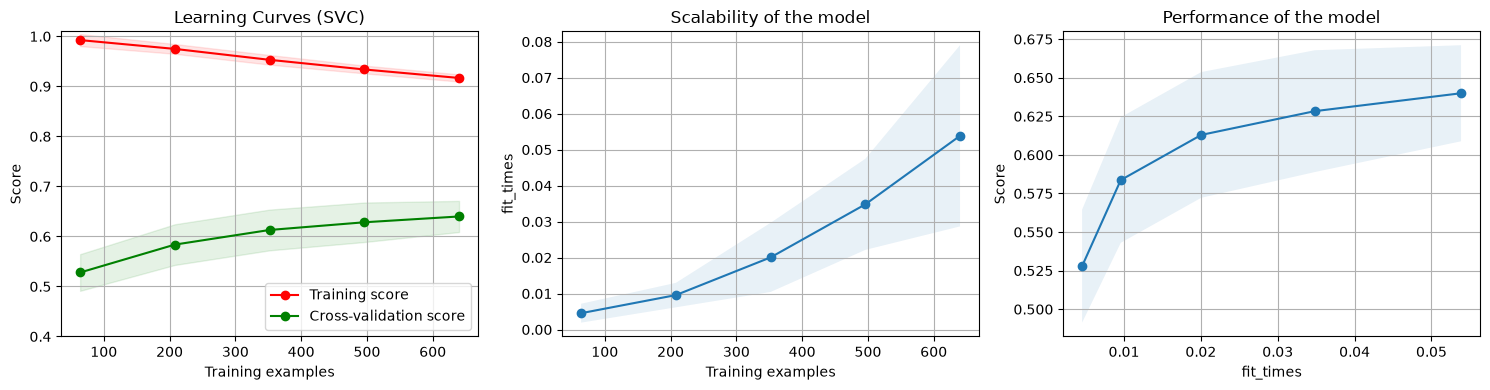

In [76]:
#Reconstruimos el conjunto de entrenamiendo y validación, sin incluir el test.
X_dev = np.concatenate((X_train, X_val))
y_dev = np.concatenate((y_train, y_val))

#Grafico de la curva de aprendizaje para el SVC con el mejor gamma encontrado.
title = "Learning Curves (SVC)"

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cv = ShuffleSplit(n_splits=100, test_size=0.2, random_state=0)
plot_learning_curve(clf, title, X_dev, y_dev, axes=axes[0:], ylim=(0.4, 1.01), cv=cv, n_jobs=4)

fig.tight_layout()
plt.show()

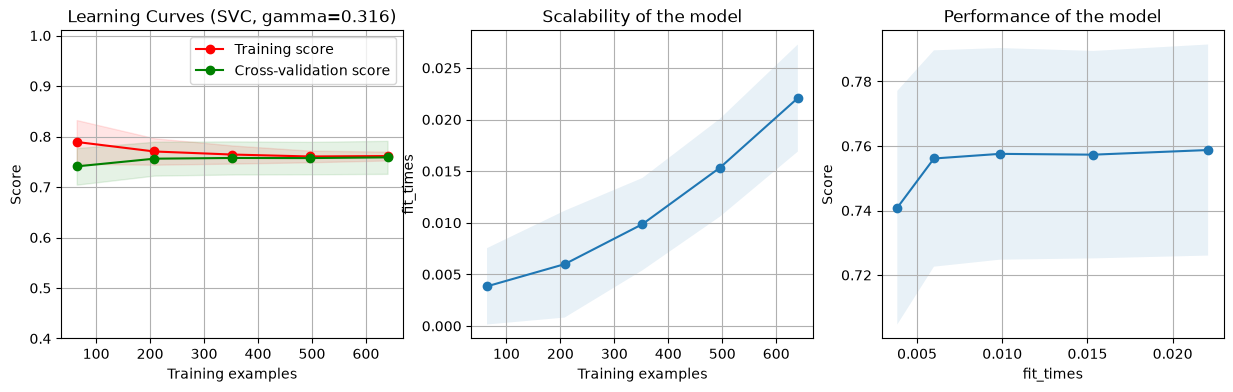

GridSearchCV - mejor gamma: 0.825
GridSearchCV - score medio CV: 0.762
GridSearchCV - score final en test: 0.810


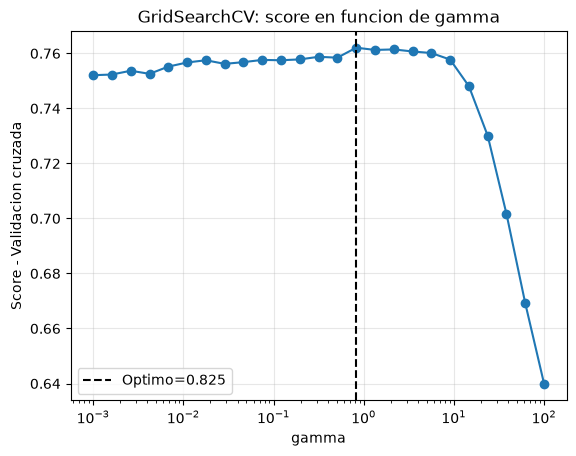

In [79]:
# Comparativa con GridSearchCV para la seleccion automatica de gamma.

# Curva de aprendizaje del SVC con el mejor gamma seleccionado manualmente.
best_model = SVC(gamma=best_gamma)

title = f'Learning Curves (SVC, gamma={best_gamma:.3g})'
fig, axes2 = plt.subplots(1, 3, figsize=(15, 4))

#ShuffleSplit para validacion cruzada con 100 iteraciones y 20% de test.
cv_learning = ShuffleSplit(n_splits=100, test_size=0.2, random_state=0)

plot_learning_curve(best_model, title, X_dev, y_dev,
                    axes=axes2, ylim=(0.4, 1.01), cv=cv_learning, n_jobs=4)
plt.show()

# Seleccion automatica de gamma mediante GridSearchCV sobre el 80% de los datos
gammas = np.logspace(-3, 2, 25)
param_grid = {'gamma': gammas}

#Busqueda de la mejor gamma mediante validacion cruzada con GridSearchCV.
busqueda = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv_learning,
    n_jobs=-1,
    refit=True,
)

busqueda.fit(X_dev, y_dev)

gamma_grid = busqueda.best_params_['gamma']
score_grid = busqueda.best_score_
score_grid_test = busqueda.score(X_test, y_test)
print(f'GridSearchCV - mejor gamma: {gamma_grid:.3g}')
print(f'GridSearchCV - score medio CV: {score_grid:.3f}')
print(f'GridSearchCV - score final en test: {score_grid_test:.3f}')

plt.figure()
plt.semilogx(param_grid['gamma'], busqueda.cv_results_['mean_test_score'], 'o-')
plt.axvline(gamma_grid, color='black', linestyle='--', label=f'Optimo={gamma_grid:.3g}')
plt.xlabel('gamma')
plt.ylabel('Score - Validacion cruzada')
plt.title('GridSearchCV: score en funcion de gamma')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


Para el modelo SVC seleccionado en el punto 1 se construyeron las curvas de aprendizaje utilizando validación cruzada y por búsqueda manueal se obtuvo el mejor gamma 0.316. Posteriormente, se utilizó GridSearchCV para seleccionar automáticamente el valor de gamma que resultó en 0.825. A pesar de la diferencia de los gammas obtenidos, los scores sobre el conjunto de test fueron muy similares: 0.805 y 0.810, respectivamente. Por tanto, ambos procedimientos responden positivamente y producen soluciones comparables para este problema.

-----

**3.** Tomando el mejor modelo para los datos ahora van crear nuevos datasets donde el modelo se espera no va a ser optimo sino que presenta overfitting y underfitting. Elegir, los párametros adecuados para los centros de medias y las matrices de covarianzas y mostrar graficamente un ejemplo de overfitting y uno de underfitting con el modelo óptimo anterior. Analizar los resultados.

Se conserva el mejor modelo seleccionado `SVC(gamma=best_gamma)` y se modifican los datos generados.

In [85]:
from scipy.stats import multivariate_normal

#Se genera un conjunto de datos bivariantes 
def generar_datos(mu0, mu1, cov0, cov1, n0, n1, random_state):
    rng = np.random.RandomState(random_state)
    X0 = multivariate_normal(mean=mu0, cov=cov0).rvs(size=n0, random_state=rng)
    X1 = multivariate_normal(mean=mu1, cov=cov1).rvs(size=n1, random_state=rng)
    X = np.concatenate((X0, X1))
    y = np.concatenate((np.zeros(n0, dtype=int), np.ones(n1, dtype=int)))
    return X, y

# OVERFITTING: pocos datos de entrenamiento y una evaluacion independiente grande.
X_over_train, y_over_train = generar_datos(
    mu0=[-1.2, 0.2], mu1=[-1.5, 1.5],
    cov0=[[1.0, 0.0], [0.0, 1.0]],
    cov1=[[1.0, -0.5], [-0.5, 1.0]],
    n0=5, n1=5, random_state=1
)
X_over_test, y_over_test = generar_datos(
    mu0=[-1.2, 0.2], mu1=[-1.5, 1.5],
    cov0=[[1.0, 0.0], [0.0, 1.0]],
    cov1=[[1.0, -0.5], [-0.5, 1.0]],
    n0=300, n1=300, random_state=100
)

over_model = SVC(gamma=best_gamma)
over_model.fit(X_over_train, y_over_train)

# UNDERFITTING: clases muy solapadas por centros cercanos y covarianzas grandes.
X_under_train, y_under_train = generar_datos(
    mu0=[0.0, 0.0], mu1=[0.3, 0.3],
    cov0=[[2.0, 0.0], [0.0, 2.0]],
    cov1=[[2.0, 0.0], [0.0, 2.0]],
    n0=300, n1=300, random_state=30
)
X_under_test, y_under_test = generar_datos(
    mu0=[0.0, 0.0], mu1=[0.3, 0.3],
    cov0=[[2.0, 0.0], [0.0, 2.0]],
    cov1=[[2.0, 0.0], [0.0, 2.0]],
    n0=300, n1=300, random_state=40
)

under_model = SVC(gamma=best_gamma)
under_model.fit(X_under_train, y_under_train)

,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",np.float64(0....2776601683794)
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


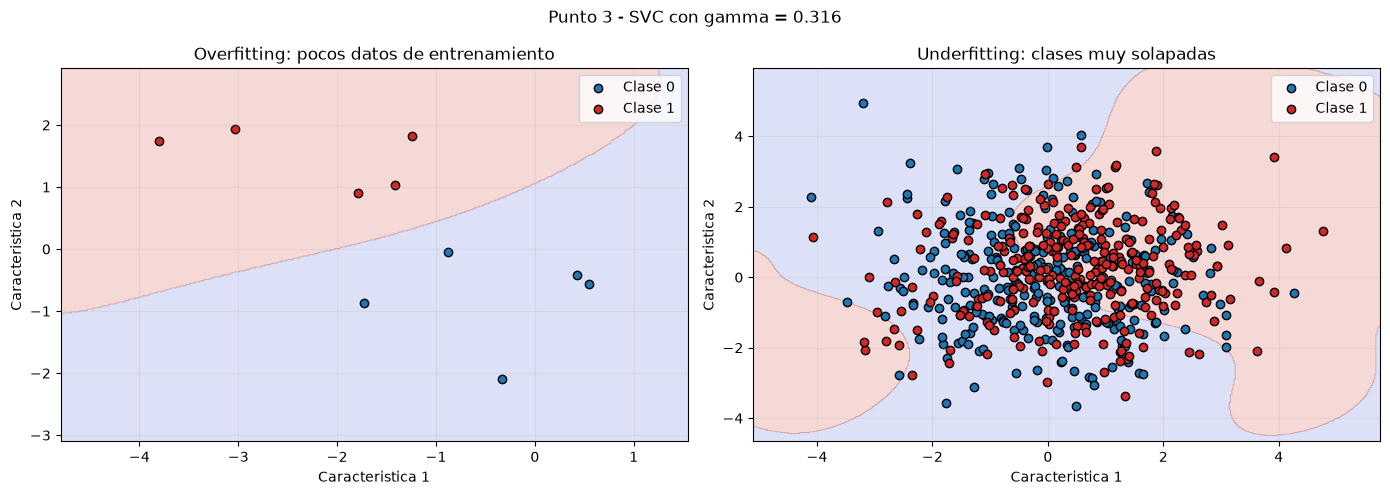

Overfitting - score entrenamiento: 1.000
Overfitting - score evaluacion:    0.717
Underfitting - score entrenamiento: 0.618
Underfitting - score evaluacion:    0.542


In [86]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

xx_over, yy_over = make_meshgrid(X_over_train[:, 0], X_over_train[:, 1])
plot_contours(axes[0], over_model, xx_over, yy_over, cmap=plt.cm.coolwarm, alpha=0.20)

axes[0].scatter(X_over_train[y_over_train == 0, 0], X_over_train[y_over_train == 0, 1], c='tab:blue', label='Clase 0', edgecolors='k')
axes[0].scatter(X_over_train[y_over_train == 1, 0], X_over_train[y_over_train == 1, 1], c='tab:red', label='Clase 1', edgecolors='k')
axes[0].set_title('Overfitting: pocos datos de entrenamiento')
axes[0].set_xlabel('Caracteristica 1')
axes[0].set_ylabel('Caracteristica 2')
axes[0].legend()
axes[0].grid(alpha=0.2)

xx_under, yy_under = make_meshgrid(X_under_train[:, 0], X_under_train[:, 1])
plot_contours(axes[1], under_model, xx_under, yy_under, cmap=plt.cm.coolwarm, alpha=0.20)

axes[1].scatter(X_under_train[y_under_train == 0, 0], X_under_train[y_under_train == 0, 1], c='tab:blue', label='Clase 0', edgecolors='k')
axes[1].scatter(X_under_train[y_under_train == 1, 0], X_under_train[y_under_train == 1, 1], c='tab:red', label='Clase 1', edgecolors='k')
axes[1].set_title('Underfitting: clases muy solapadas')
axes[1].set_xlabel('Caracteristica 1')
axes[1].set_ylabel('Caracteristica 2')
axes[1].legend()
axes[1].grid(alpha=0.2)
fig.suptitle(f'Punto 3 - SVC con gamma = {best_gamma:.3f}')
fig.tight_layout()
plt.show()

print(f'Overfitting - score entrenamiento: {over_model.score(X_over_train, y_over_train):.3f}')
print(f'Overfitting - score evaluacion:    {over_model.score(X_over_test, y_over_test):.3f}')
print(f'Underfitting - score entrenamiento: {under_model.score(X_under_train, y_under_train):.3f}')
print(f'Underfitting - score evaluacion:    {under_model.score(X_under_test, y_under_test):.3f}')

En el ejemplo de overfitting el score de entrenamiento es perfecto, pero disminuye al evaluar con datos nuevos. La diferencia entre ambos scores muestra que la frontera aprendida depende demasiado de la muestra pequeña de entrenamiento. En el ejemplo de underfitting los centros de las clases son cercanos y las covarianzas son grandes; por esto existe mucho solapamiento y los scores de entrenamiento y evaluación son bajos y parecidos.